# Import libraries

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("/Users/ekaterinasorokopudova/Desktop/Tareas repository/Sprint 13/data/df_with_fulltext_cluster_name.csv")

In [19]:
df[['queue','cluster_name','embedding']]

,queue,cluster_name,embedding
0,Technical Support,"Security, Compliance & Data Protection","[-0.0141057558, -0.0259171501, -0.00980596058,..."
1,Technical Support,"Billing, Payments, Refunds & Account Issues","[0.00852196664, 0.039423883, 0.00963402633, -0..."
2,Returns and Exchanges,"Product Features, Documentation & Technical Su...","[-0.0467852466, -0.00389463105, 0.0624952912, ..."
3,Billing and Payments,"Billing, Payments, Refunds & Account Issues","[-0.11088825, 0.03278524, 0.04811986, -0.02988..."
4,Sales and Pre-Sales,"Product Features, Documentation & Technical Su...","[-0.0165767912, 0.00369704212, 0.0265973117, -..."
...,...,...,...
28582,Technical Support,Critical Outages & Performance Disruptions,"[-0.0470882, 0.08013243, -0.07766346, -0.00605..."
28583,Product Support,"Security, Compliance & Data Protection","[0.00264201593, 0.0619929247, -0.011869085, 0...."
28584,Human Resources,"Network Connectivity, Hardware Issues & Tech S...","[0.000949101523, 0.00363543862, -0.0331395604,..."
28585,IT Support,"Product Features, Documentation & Technical Su...","[-0.0365574285, 0.0211781152, 0.000648051966, ..."


In [9]:
def fix_emb(x):
    if isinstance(x, str):
        x = x.strip("[]")
        arr = np.array([float(a) for a in x.split()])
        return arr
    return np.array(x)

In [10]:
df["embedding"] = df["embedding"].apply(fix_emb)

X = np.vstack(df["embedding"].values)
y = df["cluster_name"]


# Train/test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression

In [12]:
clf = LogisticRegression(
    max_iter=5000,
    multi_class="multinomial",
    solver="lbfgs"
)

clf.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'multinomial'


In [13]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

                                                      precision    recall  f1-score   support

         Billing, Payments, Refunds & Account Issues       1.00      0.97      0.98       230
          Critical Outages & Performance Disruptions       0.97      0.99      0.98       641
   Feature Requests, Product Improvements & Feedback       0.99      0.99      0.99       480
      IT Outages, Network Failures & System Recovery       0.98      0.96      0.97       555
 Mixed Feedback: Performance, Marketing & IT Support       0.95      0.99      0.97       503
Network Connectivity, Hardware Issues & Tech Support       0.96      0.94      0.95       833
 Product Features, Documentation & Technical Support       0.98      0.98      0.98       678
        Sales, Product Feedback & Marketing Insights       1.00      0.97      0.98       503
              Security, Compliance & Data Protection       0.99      1.00      0.99      1295

                                            accuracy      

# Confusion Matrix

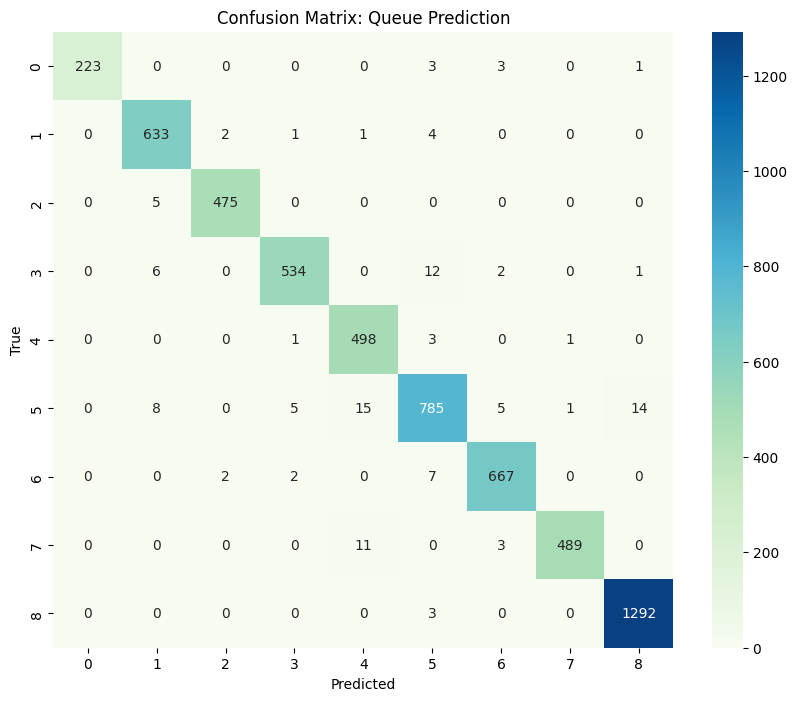

In [14]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="GnBu")
plt.title("Confusion Matrix: Queue Prediction")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

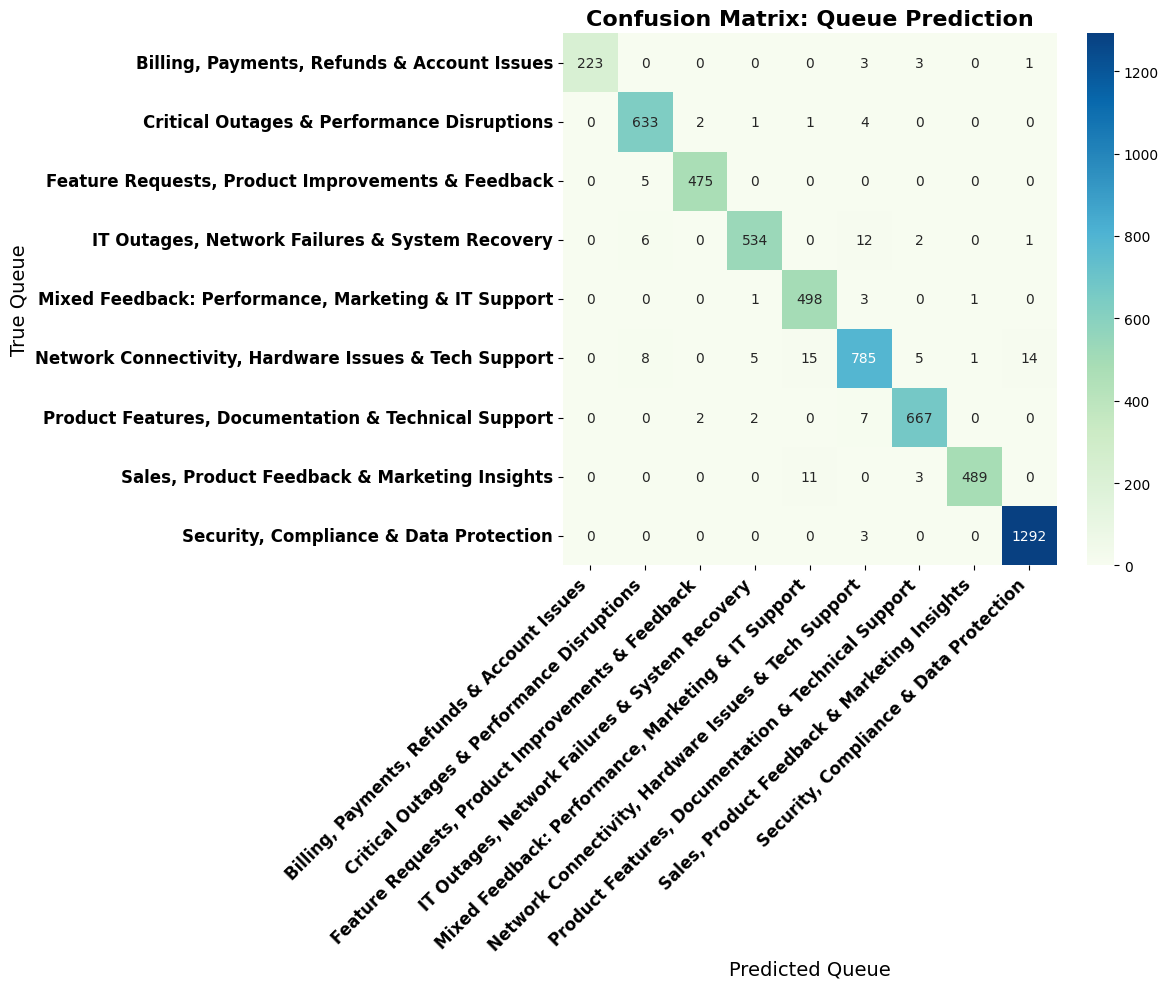

In [18]:
plt.figure(figsize=(12, 10))

cm = confusion_matrix(y_test, y_pred)
labels = sorted(y_test.unique())

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="GnBu",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix: Queue Prediction", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Queue", fontsize=14)
plt.ylabel("True Queue", fontsize=14)

plt.xticks(rotation=45, ha="right", fontsize=12, fontweight='bold')
plt.yticks(rotation=0, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
